# Training Tetris with Reinforcement Learning with Tabular Obs (DQN algo)

## C

### Imports

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import random
from itertools import count
import os

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from datetime import datetime
from a_helper import plot_all

from collections import namedtuple, deque
from tetris_env import SHAPES_IDS
from tetris_env import TetrisEnv
from a_helper import save_dqn_model
from gymnasium.wrappers import RecordEpisodeStatistics, RecordVideo

pygame 2.6.1 (SDL 2.28.4, Python 3.12.1)
Hello from the pygame community. https://www.pygame.org/contribute.html


C:\2. PersonalCoding\ia-final-project-tetris-agent\tetris_rl\venv\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


### NotebookDisplay and Device

In [2]:
is_ipython = 'inline' in matplotlib.get_backend()
if is_ipython:
    from IPython import display

plt.ion()

device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)
print(is_ipython)
print(device)

True
cuda


## Model

In [3]:
class DQN(nn.Module):
    def __init__(self, n_observations, n_actions, h_dim):
        super(DQN, self).__init__()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(n_observations, h_dim),
            nn.LayerNorm(h_dim),
            nn.ReLU(),
            nn.Linear(h_dim, h_dim),
            nn.LayerNorm(h_dim),
            nn.ReLU(),
            nn.Linear(h_dim, n_actions)
        )
        
    def forward(self, x):
        logits = self.linear_relu_stack(x)
        return logits

### ReplayMemory

In [4]:
Transition = namedtuple('Transition',
                        ('state', 'action', 'next_state', 'reward'))


class ReplayMemory(object):

    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity)

    def push(self, *args):
        """Save a transition"""
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

### Action And Optimizer

Epsilon decays after every step

In [5]:
def get_action(state, epsilon, test=False):
    sample = random.random()
    if sample > epsilon or test:
        with torch.no_grad():
            # Toma el indice de la accion con mayor y ajusta la forma del tensor
            return policy_net(state).max(1).indices.view(1, 1)
    else:
        # Escoge una accion aleatoria
        return torch.tensor([[env.action_space.sample()]], device=device, dtype=torch.long)

In [6]:
def optimize_model():
    # Mira si hay suficientes muestras (s, a, n_s, r)
    if len(memory) < BATCH_SIZE:
        return

    # Escoge muestras aleatorias de la memoria
    transitions = memory.sample(BATCH_SIZE)
    
    # Primero pasa de una lista(batch_size) de tuplas(s,a,n_s,r)
    # a una tupla(4) de tuplas (s1,s2,s3), (a1,a2,a3) ...
    # Luego lo convierte en un nuevo Transition donde cada atributo
    # (batch.state, batch.action, etc.) es una tupla con todos los elementos del batch
    batch = Transition(*zip(*transitions))

    # Crea una mask donde solo sale muestras que no acaban en done
    non_final_mask = torch.tensor(tuple(map(lambda s: s is not None,
                                          batch.next_state)), device=device, dtype=torch.bool)
    non_final_next_states = torch.cat([s for s in batch.next_state if s is not None])

    # Agrupacion de estados, acciones y recompensas
    state_batch = torch.cat(batch.state)
    action_batch = torch.cat(batch.action)
    reward_batch = torch.cat(batch.reward)
    
    # Calcula Q(s,a)
    # .gather escoge solo el valor de la accion que el agente ha realizado
    state_action_values = policy_net(state_batch).gather(1, action_batch)

    # Calcula Q Values utilizando la target_net
    next_state_values = torch.zeros(BATCH_SIZE, device=device)
    with torch.no_grad():
        next_state_values[non_final_mask] = target_net(non_final_next_states).max(1).values
    expected_state_action_values = (next_state_values * GAMMA) + reward_batch

    # Calculo de perdida
    criterion = nn.SmoothL1Loss()
    loss = criterion(state_action_values, expected_state_action_values.unsqueeze(1))

    # Optimizacion del modelo
    optimizer.zero_grad()
    loss.backward()
    
    # Gradient Clipping, limita los gradientes
    # para evitar cambios demasiado grandes en los weights de la red
    torch.nn.utils.clip_grad_value_(policy_net.parameters(), 100)
    optimizer.step()

In [7]:
from a_helper import get_six_layer_view
from a_helper import eval_bumpiness, eval_cheese, eval_sum_heights, filter_board_upper_outline, get_upper_outline_idx, eval_holes

### OneHot

In [8]:
def obs_one_hot(obs,env):
    # Retrieval
    board = obs["board"]
    queue = obs["queue"]
    piece_type = obs["piece_type"]
    hold_piece = obs["hold_piece"]
    piece_position = obs['piece_position']
    current_piece_n_action = obs["current_piece_n_action"]
    current_piece_rotation = obs["current_piece_rotation"]

    # La capa mas alta con almenos 1 bloque
    _, highest_layer_idx = get_six_layer_view(obs["board"])
    
    # Minimizar numeros a '1's
    board = np.where(board > 0, 1, board)

    # Devuelve un array(1, board.width), donde el valor de cada columna corresponde a la capa mas alta de esa columna
    board_outline_idx_vals = get_upper_outline_idx(board) / env.board_height

    # Relacionado con recompensas de tablero
    holes_val = eval_holes(board) / ((env.board_width * env.board_height) - env.board_width)
    cheese_val = eval_cheese(board) / (env.board_width * env.board_height)
    sum_heights_val = eval_sum_heights(board) / (env.board_width * env.board_height)
    bumpiness_val = eval_bumpiness(board) / (env.board_height * (env.board_width - 1))
    highest_layer_idx_val = highest_layer_idx / env.board_height
    
    # SOLO primera pieza de la queue
    first_piece_id = SHAPES_IDS[queue[0]]
    
    queue_one_hot = np.zeros(7+1) # +1 => no_piece => None
    queue_one_hot[first_piece_id] = 1
    
    piece_type_one_hot = np.zeros(7+1) # +1 => no_piece => None
    piece_type_one_hot[SHAPES_IDS[piece_type]] = 1

    hold_piece_one_hot = np.zeros(7+1) # +1 => no_piece => None
    hold_piece_one_hot[SHAPES_IDS[hold_piece]] = 1

    # Posicion
    piece_x_position_val = piece_position[0] / env.board_width
    piece_y_position_val = piece_position[1] / env.board_height

    # Finesse
    current_piece_n_action_val = np.array([min(current_piece_n_action, 20) / 20], dtype=np.float32) # 20 is considered finessen't

    current_piece_rotation_one_hot = np.zeros(4)
    current_piece_rotation_one_hot[current_piece_rotation] = 1

    final = np.concatenate((board_outline_idx_vals,
                            highest_layer_idx_val,
                            holes_val,
                            cheese_val,
                            sum_heights_val,
                            bumpiness_val,
                            current_piece_n_action_val,
                            queue_one_hot,
                            piece_type_one_hot,
                            hold_piece_one_hot, 
                            piece_x_position_val, 
                            piece_y_position_val, 
                            current_piece_rotation_one_hot,
                           ), axis=None)
    return final

## Hyper

In [9]:
# BATCH_SIZE: Numero de transiciones utilizadas para optimizar el modelo
# GAMMA: Discount Factor (que tan importante son las recompensas futuras
# en comparacion a las recompensas inmediatas
# EPS_START/EPS_END: Valor inicial y final de epsilon, respectivamente
# N_STEPS_END: Numero de steps necesarios para llegar de EPS_START a EPS_END
# TAU: Es el update rate de la network en cada step
# LR: Learning Rate
BATCH_SIZE = 128
GAMMA = 0.99
EPS_START = 1
EPS_END = 0.1
N_STEPS_END = 1_500_000
TAU = 0.001
LR = 1e-4
# Calcular cuanto tiene que decaer epsilon
EPS_DECAY = (EPS_START - EPS_END) / N_STEPS_END
steps_done = 0
print(EPS_DECAY)
print(LR)

6e-07
0.0001


## Init

In [10]:
training_period = 250 # Cada cuento graba un video
algo_id = "dqn_tabular_pytorch"
start_episode = 0

In [12]:
base_env = TetrisEnv(board_width=10,
                board_height=22,
                time_limit_s=120,
                obs_type="dict",
                render_mode='rgb_array')
env = base_env
env = RecordVideo(base_env, video_folder="videos", name_prefix=f"train-{algo_id}",
                  episode_trigger=lambda x: x % training_period == 0)
env = RecordEpisodeStatistics(env)
state, info = base_env.reset()
n_actions = base_env.action_space.n

n_observations = len(obs_one_hot(state,base_env))

print(state)
print(obs_one_hot(state,base_env))
print(n_actions, n_observations)

Using Default internal config


C:\2. PersonalCoding\ia-final-project-tetris-agent\tetris_rl\venv\Lib\site-packages\gymnasium\wrappers\rendering.py:283: UserWarning: WARN: Overwriting existing videos at C:\2. PersonalCoding\ia-final-project-tetris-agent\tetris_rl\videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


{'board': array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'queue': [np.str_('I'), np.str_('L'), np.str_('Z'), np.str_('T'), np.str_('S')], 'piece_type': np.str_('J'), 'piece_shape': array(

In [13]:
h_dim = 256
policy_net = DQN(n_observations, n_actions,h_dim).to(device)
target_net = DQN(n_observations, n_actions,h_dim).to(device)
target_net.load_state_dict(policy_net.state_dict())

optimizer = optim.AdamW(policy_net.parameters(), lr=LR, amsgrad=True)
memory = ReplayMemory(250_000)
print(policy_net)

DQN(
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=46, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=256, bias=True)
    (4): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=8, bias=True)
  )
)


In [14]:
metadata = {
    "algorithm":"DQN from PyTorch Tutorial with tabular data",
    "note": "Como observacion de la queue solo tiene la siguiente pieza, no las 5 siguientes, utiliza reward shaping",
    "hyper":{
        "BATCH_SIZE": BATCH_SIZE,
        "GAMMA": GAMMA,
        "EPS_START": EPS_START,
        "EPS_END": EPS_END,
        "EPS_DECAY": EPS_DECAY,
        "EPS_DECAY_STRAT": "Subtract after every step",
        "TAU": TAU,
        "LR": LR,
    }
}

## Load to Re-Train

In [16]:
filename = None
# filename = "dqn_tabular_pytorch_9999.pth"
checkpoint_path=f"models/{filename}"
# Cargamos el modelo
if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, weights_only=False,map_location=device)
    start_episode = checkpoint['episode'] + 1
    policy_net.load_state_dict(checkpoint['policy_net'])
    target_net.load_state_dict(checkpoint['target_net'])
    optimizer.load_state_dict(checkpoint['optimizer'])
    memory = checkpoint['memory']
    env.internal_config = checkpoint['env_internal_config']
    metadata = checkpoint['metadata']
    
    print(f"Loaded checkpoint from episode {start_episode}")
    print(metadata)
    policy_net.train()
    target_net.train()
else:
    print("Checkpoint Not Found, starting from zero")

Checkpoint Not Found, starting from zero


## Main Train

epsilon 0.9993652
episode 9
-914.9783333333332
Checkpoint saved at episode 9


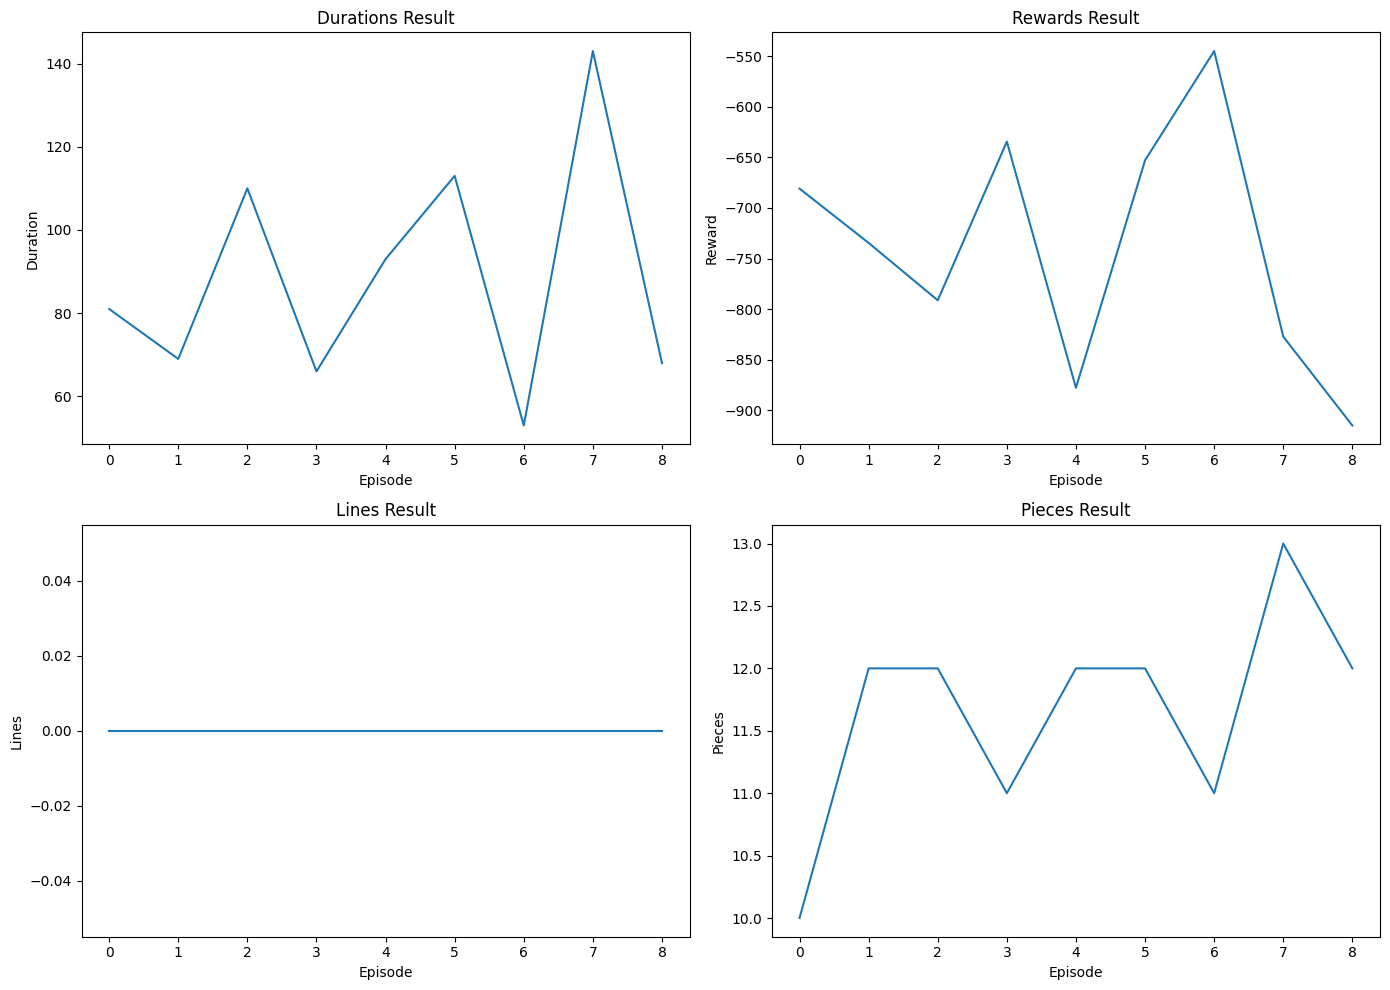

Complete


In [18]:
total_episodes = 10
episode_durations = []
episode_rewards = []
episode_lines = []
episode_pieces = []

for i_episode in range(total_episodes):
    state, info = env.reset()
    state = obs_one_hot(state,base_env)
    state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    total_reward = 0
    done = False
    for t in count():
        steps_done += 1
        epsilon = max(EPS_END, EPS_START - steps_done * EPS_DECAY)
        action = get_action(state, epsilon)
        observation, reward, terminated, truncated, info = env.step(action.item())
        observation = obs_one_hot(observation,base_env)
        reward = torch.tensor([reward], device=device)
        total_reward += reward.item()
        done = terminated or truncated

        if terminated:
            next_state = None
        else:
            next_state = torch.tensor(observation, dtype=torch.float32, device=device).unsqueeze(0)

        memory.push(state, action, next_state, reward)

        state = next_state

        optimize_model()

        # Soft update of the target network's weights
        # θ′ ← τ * θ + (1 −τ )θ′
        target_net_state_dict = target_net.state_dict()
        policy_net_state_dict = policy_net.state_dict()
        for key in policy_net_state_dict:
            target_net_state_dict[key] = policy_net_state_dict[key]*TAU + target_net_state_dict[key]*(1-TAU)
        target_net.load_state_dict(target_net_state_dict)

        if done:
            episode_durations.append(t + 1)
            episode_rewards.append(total_reward)
            episode_lines.append(info['lines_cleared'])
            episode_pieces.append(info['pieces_placed'])
            plot_all(episode_durations,episode_rewards,episode_lines,episode_pieces)
            print("epsilon", epsilon)
            print("episode",i_episode+start_episode)
            print(total_reward)
            break

    if i_episode % 1000 == 0:
        save_dqn_model(i_episode+start_episode,policy_net,target_net,optimizer,memory,base_env,f"models/{algo_id}_{i_episode+start_episode}.pth",metadata)

    # prevent memory death
    if i_episode % 500 == 0:
        plot_all(episode_durations,episode_rewards,episode_lines,episode_pieces,save=True,show_result=True,filename=f"plots/train_{algo_id}_{i_episode+start_episode}.png")
        episode_durations = []
        episode_rewards = []
        episode_lines = []
        episode_pieces = []

save_dqn_model(i_episode+start_episode,policy_net,target_net,optimizer,memory,base_env,f"models/{algo_id}_{i_episode+start_episode}.pth",metadata)
plot_all(episode_durations,episode_rewards,episode_lines,episode_pieces,save=True,show_result=True,filename=f"plots/train_{algo_id}_{i_episode+start_episode}.png")
plt.ioff()
plt.show() 
env.close()
print('Complete')